In [1]:
from datetime import date

import arviz as az
import blackjax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer.reparam import TransformReparam
from numpyro.infer.util import initialize_model

J = 8
y = np.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0])
sigma = np.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0])

rng_key = jax.random.key(int(date.today().strftime("%Y%m%d")))


def eight_schools_noncentered(J, sigma, y=None):
    mu = numpyro.sample("mu", dist.Normal(0, 5))
    tau = numpyro.sample("tau", dist.HalfCauchy(5))
    with numpyro.plate("J", J):
        with numpyro.handlers.reparam(config={"theta": TransformReparam()}):
            theta = numpyro.sample(
                "theta",
                dist.TransformedDistribution(
                    dist.Normal(0.0, 1.0), dist.transforms.AffineTransform(mu, tau)
                ),
            )
        numpyro.sample("obs", dist.Normal(theta, sigma), obs=y)


rng_key, init_key = jax.random.split(rng_key)
init_params, potential_fn_gen, *_ = initialize_model(
    init_key,
    eight_schools_noncentered,
    model_args=(J, sigma, y),
    dynamic_args=True,
)


def logdensity_fn(position):
    return -potential_fn_gen(J, sigma, y)(position)


/Users/yutai/miniconda3/envs/bnn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def inference_loop(rng_key, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, rng_key):
        state, info = kernel(rng_key, state)
        return state, (state, info)

    keys = jax.random.split(rng_key, num_samples)
    _, (states, infos) = jax.lax.scan(one_step, initial_state, keys)

    return states, (
        infos.acceptance_rate,
        infos.is_divergent,
        infos.num_integration_steps,
    )


initial_position = init_params.z
num_warmup = 2000

adapt = blackjax.window_adaptation(
    blackjax.nuts, logdensity_fn, target_acceptance_rate=0.8
)
rng_key, warmup_key = jax.random.split(rng_key)
(last_state, parameters), _ = adapt.run(warmup_key, initial_position, num_warmup)
kernel = blackjax.nuts(logdensity_fn, **parameters).step


num_sample = 1000
rng_key, sample_key = jax.random.split(rng_key)
states, infos = inference_loop(sample_key, kernel, last_state, num_sample)
# _ = states.position["mu"].block_until_ready()

In [3]:
print(states._fields)
for k, v in states.position.items():
    print(k, v.shape)

# print()
# for k, v in states.position.items():
#     print(k, jnp.tile(v[None, ...], (3, 1)).shape)


('position', 'logdensity', 'logdensity_grad')
mu (1000,)
tau (1000,)
theta_base (1000, 8)


In [4]:
def tile_first_dim(x, reps):
    expanded = x[None, ...]
    tile_seq = (reps,) + (1,) * x.ndim
    return jnp.tile(expanded, tile_seq)

array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'tau'}>],
      dtype=object)

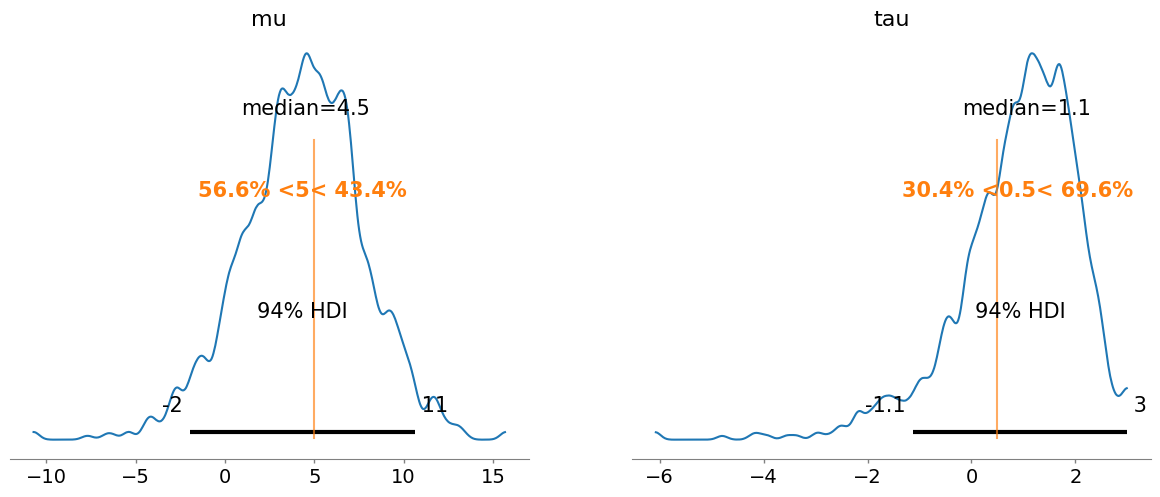

In [5]:
from weakref import ref

reps = 3
posterior_dict = {k: tile_first_dim(v, reps) for k, v in states.position.items()}
idata = az.from_dict(posterior=posterior_dict)
az.plot_posterior(
    idata,
    var_names=["mu", "tau"],
    point_estimate="median",
    ref_val=[5, 0.5],
)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

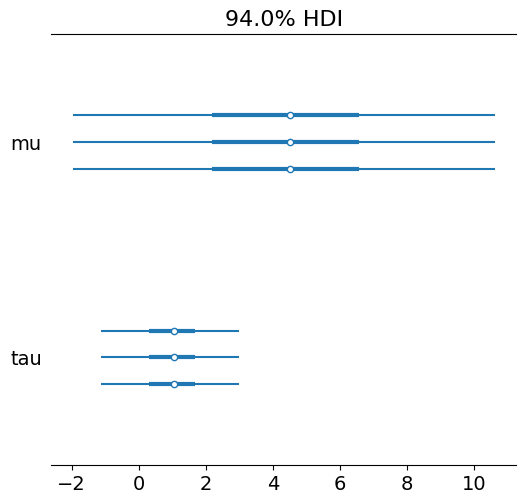

In [6]:
reps = 3
posterior_dict = {k: tile_first_dim(v, reps) for k, v in states.position.items()}
idata = az.from_dict(posterior=posterior_dict)
az.plot_forest(idata, var_names=["mu", "tau"])

mu (3, 1000)
tau (3, 1000)
theta_base (3, 1000, 8)


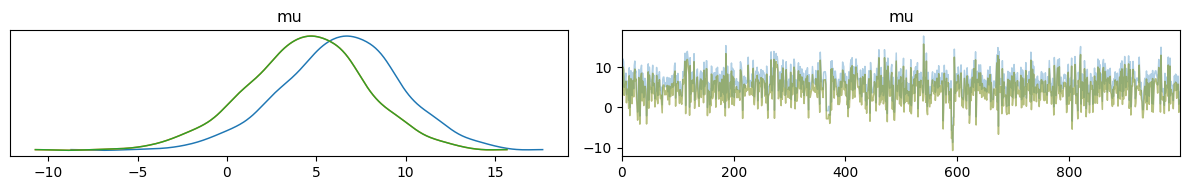

In [7]:
reps = 3
posterior_dict = {k: tile_first_dim(v, reps) for k, v in states.position.items()}
new_chain = posterior_dict["mu"].at[0, :].add(2)
posterior_dict["mu"] = new_chain

for k, v in posterior_dict.items():
    print(k, v.shape)
idata = az.from_dict(posterior=posterior_dict)

coords = {"school": ["Choate", "Lawrenceville"]}
lines = (("mu", {"school": "Choate"}, [0, 1]),)

az.plot_trace(
    idata,
    var_names=["mu"],
    compact=False,
    lines=lines,
)
plt.tight_layout();


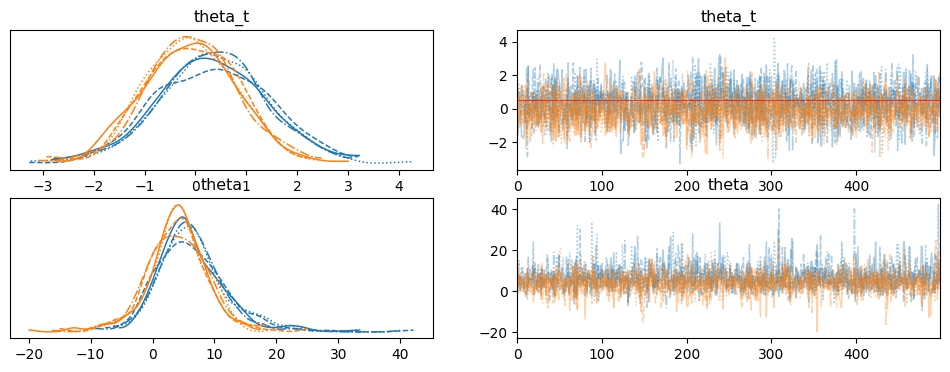

In [8]:
import arviz as az

data = az.load_arviz_data("non_centered_eight")
coords = {"school": ["Choate", "Lawrenceville"]}
lines = (("theta_t", {"school": "Choate"}, [-1]),)
f = az.plot_trace(
    data,
    var_names=("theta_t", "theta"),
    coords=coords,
    lines=lines,
)
f[0, 1].axhline(0.5, color="red", label="True", lw=0.5)
